# A robust script to take 2D or 3D output from CESM as well as 2D or 3D ouutput from obs. and reanalysis to:plot
### 1. Zonal Averages for 1D (done)
### 2. Lat-Lon averages for 2D (done)
### 3. Zonal average for 3D
### 4. Lat-lon slices for 2D on a pressure surface 
### 5. Column regional averages
### 6. Meridional slice avaregs (default 5S-5N)
### 7. Meridional 2D slice averages

In [1]:
import xarray as xr
import matplotlib.pyplot as mp
import numpy as np
import glob as glob

import cartopy.crs as ccrs

import importlib
import general_cesm_plot_utils as mypy_utils


In [2]:
from dask.distributed import Client
from ncar_jobqueue import NCARCluster

cluster = NCARCluster(account='P93300042',interface='mgt', job_extra_directives=[],walltime="12:00:00")
cluster
cluster.scale(jobs=8)
client = Client(cluster)
client

/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/ncar_jobqueue/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/dask_jobqueue/core.py:285: FutureWa

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.18.206.48:43589,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [80]:
# Replace with your actual file paths and variable name

# Import



dir0 = '/glade/derecho/scratch/rneale/archive/'
dir_climo = '/glade/campaign/cgd/amp/amwg/climo/'
dir_obs = '/glade/campaign/cgd/amp/amwg/amwg_data/obs_data/'
dir_fig = '/glade/u/home/rneale/python/python-figs/CAM7_CESM3_dev/'



seas = 'ANN'

lfcase = 2  # Plot CAM and not CESMcases.
lanom_plot = False  # Will plot the first case, and then subsequence cases plots the difference from ths first case

plot_type = "latlon" # Options [lat,latlon,latpres]

mask_ocn = False

pregion = 'IndoPac' # Options [LabSea, IO, US, SAm, Aus, TP, WP, IndoPac, Tropics, NPolar]
#pregion = 'Boreal'


'''
    ################### VARIABLE TO PLOT ################
'''
obs_cases = []



## 2D variables
#var = 'PRECC' ; obs_cases = ['']
var = 'PRECT' ; obs_cases = ['GPCP']
#var = 'CLDLOW' ; obs_cases = []
#var = 'SWCF' ; obs_cases = ['CERES-EBAF','CERES2']
#var = 'LWCF' ; obs_cases = ['CERES-EBAF','CERES2']
#var = 'LHFLX' ; obs_cases = ['LARYEA','ERAI']
#var = 'SHFLX' ; obs_cases = ['JRA25','LARYEA']
#var = 'TMQ' ; obs_cases = ['NVAP']

#var = 'PCONVT' ; obs_cases = []
#var = 'TAUX' ; obs_cases = ['MERRA']
#var = 'TAUY' ; obs_cases = ['MERRA']

# 3D variables

#var = 'Q' ; obs_cases = ['MERRA']
#var = 'TS' ; obs_cases = ['HadISST_PI']




#var = 'SFbc_a4' ; obs_cases = []
#var = 'SFpom_a4' 
#var = 'SFso4_a1' 
#var = 'pom_a4_CLXF' 
#var = 'pom_a4' ; vproc = 'pvint'


vproc = 'vint'

'''
    ################# CASE SELECTION ############
'''

if lfcase == 1:

    fig_pref = 'CAM7-bulkflux_sens_runs'

    dcases = {'CAM7-032'          : 'f.cam6_4_032.FLTHIST_ne30.cam7_dev.002',
              'CAM7-089'          : 'f.cam6_4_089.FLTHIST_ne30.cam7.001',
              '0.75*lhf'          : 'f.e30_cam6_4_078.FHISTC_LTso.ne30.lhf_roughphis_SGH_grlnd28k.001',
              'qsat (T2m)'         : 'f.e30_cam6_4_078.FHISTC_LTso.ne30.ssq_T2m_roughphis_SGH_grlnd28k.001',
              'flux all (T2m)'     : 'f.e30_cam6_4_078.FHISTC_LTso.ne30.flux_all_T2m_roughphis_SGH_grlnd28k.001',
              'flux all (T2m:SST)' :'f.e30_cam6_4_078.FHISTC_LTso.ne30.flux_all_Tsave_roughphis_SGH_grlnd28k.001',
              'UA'                 :'f.e30_cam6_4_078.FHISTC_LTso.ne30.ocnflx2_roughphis_SGH_grlnd28k.001',
              'G&G qsat'           :'f.e30_cam6_4_078.FHISTC_LTso.ne30.baseline156_qsat.001'}



#    dcases = {'089 bline'    : 'f.cam6_4_089.FLTHIST_ne30.cam7.001',
#              'dmpdz.001a'    : 'f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a',
#              'dmpdz.005b'    : 'f.cam6_4_032.FLTHIST_ne30.cam7_ke.005b',
#              'dmpdz.089'    : 'f.cam6_4_089.FLTHIST_ne30.cam7_zm_dmpdz.002',
#              'zmke.001'     : 'f.cam6_4_089.FLTHIST_ne30.cam7_zm_ke.001',
#              'zmke.002b'     : 'f.cam6_4_032.FLTHIST_ne30.cam7_ke.002b',
#              'zmke.003b'     : 'f.cam6_4_032.FLTHIST_ne30.cam7_ke.003b',
#              'pblpar.001'     : 'f.cam6_4_089.FLTHIST_ne30.cam7_zm_pblpar.001',
#              'pblpar.002'     : 'f.cam6_4_089.FLTHIST_ne30.cam7_zm_pblpar.002'
#             }             

#    dcases = {'CAM7-089'    : 'f.cam6_4_089.FLTHIST_ne30.cam7.001',
#              'dmpdz-5k'     :'f.cam6_4_089.FLTHIST_ne30.cam7_zm_dmpdz.002',
#              'dmpdz-3k'     :'f.cam6_4_089.FLTHIST_ne30.cam7_zm_dmpdz.003',   
#              'KE-par'       : 'f.cam6_4_089.FLTHIST_ne30.cam7_zm_ke.001',
#              'zmpar-1.0pblh'      : 'f.cam6_4_089.FLTHIST_ne30.cam7_zm_pblpar.001',
#              'zmpar-0.25pblh'     : 'f.cam6_4_089.FLTHIST_ne30.cam7_zm_pblpar.002'
#             }    


#  dcases = {'dmpdz.01a'    : 'f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a',
#              'dmpdz.04b'    : 'f.cam6_4_032.FLTHIST_ne30.cam7_ke.004b',
#              'dmpdz.05b'    : 'f.cam6_4_032.FLTHIST_ne30.cam7_ke.005b',
#              'dmpdz.089'    : 'f.cam6_4_089.FLTHIST_ne30.cam7_zm_dmpdz.002',
#              'dmpdz.07b'    : 'f.cam6_4_032.FLTHIST_ne30.cam7_ke.007b',
#              'dmpdz.08b'    : 'f.cam6_4_032.FLTHIST_ne30.cam7_ke.008b',
#              'dmpdz.09b'    : 'f.cam6_4_032.FLTHIST_ne30.cam7_ke.009b',
#              'dmpdz.10b'    : 'f.cam6_4_032.FLTHIST_ne30.cam7_ke.010b',
#              'dmpdz.11b'    : 'f.cam6_4_032.FLTHIST_ne30.cam7_ke.011b'}

#    fig_pref = 'CAM7-ZM-sens'

#    dcases = {'032'      : 'f.cam6_4_032.FLTHIST_ne30.cam7_dev.002',
#              '089'      : 'f.cam6_4_089.FLTHIST_ne30.cam7.001',
#              '089dmpdz'      : 'f.cam6_4_089.FLTHIST_ne30.cam7_zm_dmpdz.001',
#              '0.5xtau'  : 'f.cam6_4_089.FLTHIST_ne30.cam7_zm_tau_x0.5.001',
#              '2xtau'    : 'f.cam6_4_089.FLTHIST_ne30.cam7_zm_tau_x2.001',
#              'cmt_0.4'  : 'f.cam6_4_032.FLTHIST_ne30.cam7_dev.005',
#              'cmt_0.1'  : 'f.cam6_4_032.FLTHIST_ne30.cam7_dev.006',
#              'tiedke 0K' : 'f.cam6_4_089.FLTHIST_ne30.cam7_zm_tiedke0K.001',
#              'tiedke 2K'    : 'f.cam6_4_089.FLTHIST_ne30.cam7_zm_tiedke2K.001',
#              'c0_lnd_ocn'    : 'f.cam6_4_089.FLTHIST_ne30.cam7_zm_c0_lnd.001', }

#    fig_pref = 'CAM7-ZM-sens_subset'

#    dcases = {'CAM6'      : 'f.e20.FHIST.f09_f09.cesm2_1.001',
#              'CAM7-089'      : 'f.cam6_4_089.FLTHIST_ne30.cam7.001',
#              'tiedke 0K' : 'f.cam6_4_089.FLTHIST_ne30.cam7_zm_tiedke0K.001',
#              'tiedke 2K'    : 'f.cam6_4_089.FLTHIST_ne30.cam7_zm_tiedke2K.001',}

    fig_pref = 'CAM7-ZM-sens_subset2'
    
    dcases = {'CAM6'      : 'f.e20.FHIST.f09_f09.cesm2_1.001',
              'CAM7-089'      : 'f.cam6_4_089.FLTHIST_ne30.cam7.001',
              'tiedke 0K' : 'f.cam6_4_089.FLTHIST_ne30.cam7_zm_tiedke0K.001',
              'tiedke 2K'    : 'f.cam6_4_089.FLTHIST_ne30.cam7_zm_tiedke2K.001',
              'alfa 0.05' : 'f.cam6_4_032.FLTHIST_ne30.cam7_dev.007',
              'alfa 0.25' : 'f.cam6_4_032.FLTHIST_ne30.cam7_dev.008',
              'KE def.' : 'f.cam6_4_032.FLTHIST_ne30.cam7_ke.002b',
              'KE TKE.' : 'f.cam6_4_032.FLTHIST_ne30.cam7_ke.003b',
              'KE def2..' : 'f.cam6_4_032.FLTHIST_ne30.cam7_ke.008b',
              'tscool=-30' :'f.cam6_4_089.FLTHIST_ne30.cam7_zm_tscool.001',
              'dmpdz 5k'    : 'f.cam6_4_089.FLTHIST_ne30.cam7_zm_dmpdz.002', 
              'dmpdz x2 low 3k'    : 'f.cam6_4_032.FLTHIST_ne30.cam7_ke.007b',
             }


if lfcase == 2:

    fig_pref = 'CAM7_to_CESM3_bias'
    
    dcases = {'Uncoupled Bias' : 'f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a',
             'Uncoupled Bias (with change)' : 'f.cam6_4_032.FLTHIST_ne30.cam7_ke.002b',
             'Coupled Biasx': 'b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.192', 
              'Coupled Bias': 'b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.192', 
              'Coupled Bias (with change)': 'b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.193',          
             }

#    dcases = {'CESM3 (198)': 'b.e30_alpha07b_dev.B1850C_LTso.ne30_t232_wgx3.198', 
#              'CAM7 (AMIP)' : 'f.cam6_4_089.FLTHIST_ne30.cam7.001',
#              'CESM2' : 'b.e20.B1850.f09_g17.pi_control.all.297',
#              'CESM1' : 'b.e11.B1850C5CN.f09_g16.005'}


#    fig_pref = 'CAM7_to_CESM3_bias'
    
#    dcases = {'237': 'b.e30_alpha07c_cesm.B1850C_LTso.ne30_t232_wgx3.237', 
#              '238': 'b.e30_alpha07c_cesm.B1850C_LTso.ne30_t232_wgx3.238',
#              '240': 'b.e30_alpha07c_cesm.B1850C_LTso.ne30_t232_wgx3.240', 
#              'CESM2' : 'b.e20.B1850.f09_g17.pi_control.all.297',
#              'CESM1' : 'b.e11.B1850C5CN.f09_g16.005'}



if lfcase == 3:

    fig_pref = 'aero_bb_bc_sims'

    dir_fig = '/glade/u/home/rneale/python/python-figs/aerosols/'

    
    if pregion == 'SAm':

        nrow_scale = 3
        ncol_scale = 5
        
        dcases = {   'Control'    : 'f.e21.F2000climo.f19_f19.cesm2_1.dfires.000',                 
                  'Global 0.5x'    : 'f.e21.F2000climo.f19_f19.cesm2_1.dfires.002a',
                  'Global 2.0x'    : 'f.e21.F2000climo.f19_f19.cesm2_1.dfires.001a',
                  'Global 10.0x'    : 'f.e21.F2000climo.f19_f19.cesm2_1.dfires.009a',
                  'Amazon 0.5x'    : 'f.e21.F2000climo.f19_f19.cesm2_1.dfires.007a',
                  'Amazon 2.0x'    : 'f.e21.F2000climo.f19_f19.cesm2_1.dfires.006a',
                  'Amazon 10.0x'    : 'f.e21.F2000climo.f19_f19.cesm2_1.dfires.008a'}

    

    
    if pregion == 'Boreal':

        nrow_scale = 6
        ncol_scale = 4
        
        dcases = {  'Control'    : 'f.e21.F2000climo.f19_f19.cesm2_1.dfires.000',
                  'Global 0.5x'    : 'f.e21.F2000climo.f19_f19.cesm2_1.dfires.002a',
                  'Global 2.0x'    : 'f.e21.F2000climo.f19_f19.cesm2_1.dfires.001a',
                  'Global 10.0x'    : 'f.e21.F2000climo.f19_f19.cesm2_1.dfires.009a',
                  'Boreal 0.5x'    : 'f.e21.F2000climo.f19_f19.cesm2_1.dfires.004a',
                  'Boreal 2.0x'    : 'f.e21.F2000climo.f19_f19.cesm2_1.dfires.003a',
                  'Boreal 10.0x'    : 'f.e21.F2000climo.f19_f19.cesm2_1.dfires.005a'}



if lfcase == 4:

        fig_pref = 'aero_bb_bc_sims'
    
        nrow_scale = 1
        ncol_scale = 3
        
        dcases = { 'FMTHIST (numcin=3)'    : 'QBOtune_frontbugfix_zmcin3_eff015_fmt_c64116',
                   'FMTHIST (numcin=1)'    : 'CTL_fmt_c64116',
                 } 














case_names = list(dcases.keys())
cases = [v for v in dcases.values()]



vmask_ocn = ['SHFLX','LHFLX','TMQ','TAUY','TAUX'] # These are masked just over ocean by default


cases = obs_cases+cases if obs_cases != [''] else cases
case_names = obs_cases+case_names if obs_cases != [''] else case_names
nobs = len(obs_cases) if obs_cases != [''] else 0


ncases = len(cases)
pcases = ncases


obs_set = ['GPCP','TRMM','CERES2','CERES-EBAF','ERBE','ERAI','JRA25','MERRA','LARYEA','WHOI','NVAP','ERS','SSMI','HadISST_PI','HadSST_PD']


# Set plot set logicals

if plot_type not in ['lat','latlon','latpres'] :
    print(" **** UNRECOGNIZED PLOT TYPE. ALLOWED TYPES ARE - ['lat','latlon','latpres']")

pregions = ['NPolar','SPolar','LabSea', 'IO', 'US', 'SAm', 'Aus', 'TP','WP', 'Tropics','IndoPac']
if pregion not in pregions:
    print(" **** UNRECOGNIZED PLOT REGION. ALLOWED REGIONS ARE ...")        
    print(pregions) 
                   
if 'plot_sub_nums' not in locals():
    plot_sub_nums = list(range(ncases))





Plotting ***  PRECT  *** for the following region and cases
Region *** IndoPac  ***
 - GPCP
 - f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a
 - f.cam6_4_032.FLTHIST_ne30.cam7_ke.002b
 - b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.192
 - b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.192
 - b.e30_beta06.B1850C_LTso.ne30_t232_wgx3.193

Case -  [1]  of  [6]  -  GPCP 
/glade/campaign/cgd/amp/amwg/amwg_data/obs_data/GPCP_ANN_climo.nc
 - Opening case dataset -
 - Configuring variables -
 - Processing variable ready for plotting -
 - Plotting -

Case -  [2]  of  [6]  -  f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a 
/glade/derecho/scratch/rneale/archive/f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a/climo/f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a_ANN_climo.nc
 - Opening case dataset -
 - Configuring variables -
 - Processing variable ready for plotting -
 - Plotting -

Case -  [3]  of  [6]  -  f.cam6_4_032.FLTHIST_ne30.cam7_ke.002b 
/glade/derecho/scratch/rneale/archive/f.cam6_4_032.FLTHIST_ne30.cam7_ke.002b/climo/f.cam6_4_032

/glade/work/rneale/git/python-scripts/CAM7_CESM3_dev/general_cesm_plot_utils.py:279: UserWarning: The figure layout has changed to tight
  



************
* Finished *
************



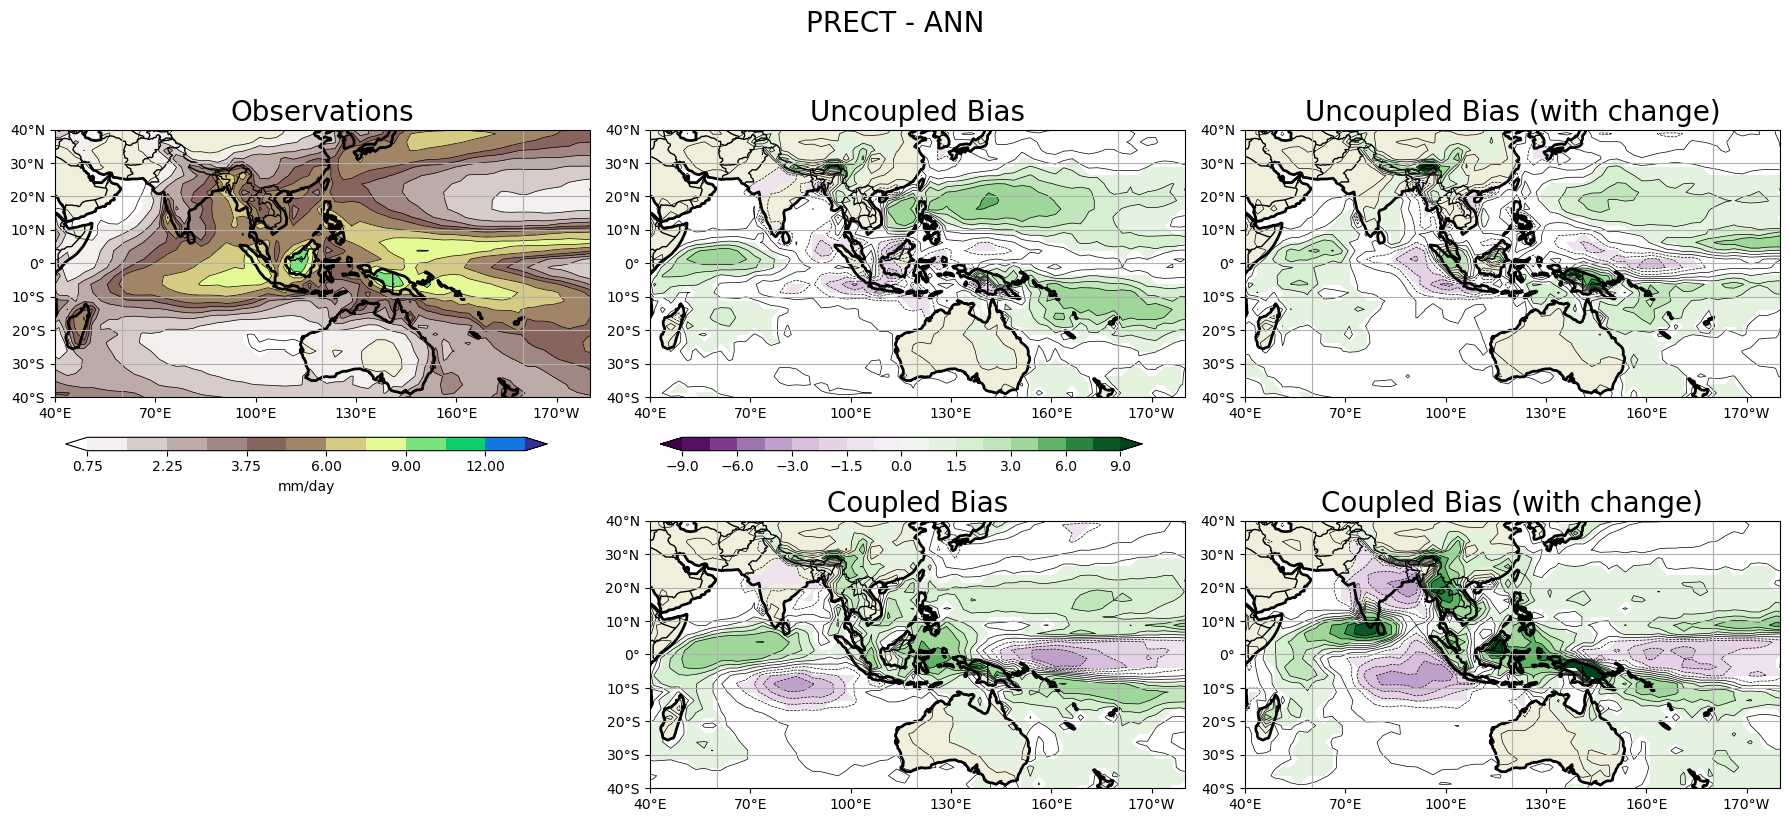

In [81]:

importlib.reload(mypy_utils) # Required because I am constantly editing scam_func.py


## Need to tie the below up into a function

match plot_type:
    case 'lat':
        nrows = 1 
        ncols = 1
        fig, ax = mp.subplots(figsize=[12, 8])    
    
    case 'latlon':
        nrows = 2
        ncols = 3

        if pregion in ['NPolar','SPolar']:

            fig, axs = mp.subplots(nrows=nrows, ncols=ncols, figsize=[ncols*4, nrows*12.],
                           subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=0.)}, constrained_layout=True)  
        
        else:
        
            fig, axs = mp.subplots(nrows=nrows, ncols=ncols, figsize=[ncols*6, nrows*4.5],
                           subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180.)}, constrained_layout=True)    
        ax = axs.flatten()
    
    case 'latpres':
    
        nrows = 3
        ncols = 3
        
        fig, axs = mp.subplots(nrows=nrows, ncols=ncols, figsize=[ncols*6, nrows*5], constrained_layout=True)
        ax = axs.flatten()

# Total number of sub-panels reserved
nsplots = nrows*ncols

if nrows*ncols > ncases : print("** Too many panels for ncases")
if nrows*ncols < ncases : print("** Too few  panels for ncases")


print('')
print('Plotting *** ',var,' *** for the following region and cases')
print('Region ***',pregion,' ***')

fcases = '\n'.join(f" - {item}" for item in cases)


print(fcases)



# Set default that var_save isn't needed
var_save = None



















''' 
    LOOP FOR PLOTS (Could include empty plots) 
'''

nskip_panel = -1
splots = list(range(ncases))


if nskip_panel >= 0:
    ax[nskip_panel].set_visible(False)


for icase, case in enumerate(cases[0:pcases]):    

    isplot = splots[icase]
    
    print('')
    print('\033[1mCase - ',[icase+1],' of ',[ncases],' - ',case,'\033[0m' )
    cname = case_names[icase]
    llast_case = icase == ncases-1 # Is this the last case.

    is_obs = case in obs_set

# Obs and 2 climo types file selection.
    if is_obs:
        case_file = dir_obs+case+'_'+seas+'_climo.nc'        
    else:
        if 'b.e30xxxxxx' in case:
            print(case)
            print(dir_climo)
            case_file = glob.glob(dir_climo+case+'/*/'+case+'_'+var+'_climo.nc')[0]  
        else:
            case_file = dir0+case+'/climo/'+case+'_'+seas+'_climo.nc'
            
    print(case_file)
    
# Open dataset

    print(' - Opening case dataset -')

    ds = xr.open_dataset(case_file,decode_times = False, chunks={})
   
# Extract variable/obs. specific information

    var_info = mypy_utils.set_var_params(ds,var,case)

    var_from_file = var_info[var][case][1] if is_obs else var
    vscale = var_info[var][case][0]      if is_obs else var_info[var]['vscale']
    vunits = var_info[var]['vunits']
    voffset = 0.

    
    if not is_obs:
        voffset = var_info[var]['voffset'] if 'voffset' in var_info[var] else 0.

    
# Grab variable or derived variable from file(s)

    var_in,ds = mypy_utils.getvar_derived(ds,var_from_file,seas)
    var_in = var_in*vscale+voffset
    


# Masking option (if in variable masking array)

    if var in vmask_ocn : var_in = mypy_utils.apply_land_mask(ds,var_in)
    
# Anomalies from icase = 0?

    print(' - Configuring variables -')
    var_plot, var_save = mypy_utils.var_forplot(ds,var_in,var,var_save,icase,lanom_plot,is_obs,vproc)

# Plotting options

    print(' - Plotting -')
    
    if plot_type in ['lat','lon']:
        zonal_mean = var_plot.sel(lat=slice(-40, 40)).mean(dim='lon', skipna=True)
        params_plot = mypy_utils.set_params_lat(icase,case,obs_set,nobs)
        mypy_utils.plot_lat(ax,fig,icase,var,zonal_mean,vunits,cname,seas,mask_ocn,lanom_plot,llast_case,params_plot)

    if plot_type == 'latlon' and isplot != 3:
        params_plot = mypy_utils.set_params_latlon(icase,ncases,var,obs_set,lanom_plot)
        mypy_utils.plot_latlon(ax[isplot],fig,icase,var,var_plot,vunits,cname,seas,pregion,mask_ocn,lanom_plot,llast_case,params_plot)

    if plot_type in ['latpres','pres']:
        zonal_mean = var_plot.mean(dim='lon', skipna=True)
        params_plot = mypy_utils.set_params_latpres(icase,ncases,var,obs_set,lanom_plot)
        mypy_utils.plot_latpres(ax[isplot],fig,icase,zonal_mean,vunits,cname,seas,lanom_plot,llast_case,params_plot)


#fig.suptitle(var+' - '+seas, fontweight='bold', fontsize=20)


# Set unused ax[icase] to blank
for ix in range(ncases,nrows*ncols): ax[ix].set_visible(False)
ax[3].set_visible(False)    

# png output file


print('')
print('************')
print('* Finished *')
print('************')
print('')

fig_file = dir_fig+fig_pref+'_'+var+'_'+seas+'_'+pregion+'_'+plot_type+'_panel.png'




fig.savefig(fig_file)
fig.show()

